# Assignment 3 - Building a Custom Visualization

In this assignment you must choose __one__ of the options presented below and submit a visual as well as your source code for peer grading. The details of how you solve the assignment are up to you, although your assignment must use matplotlib so that your peers can evaluate your work. The options differ in challenge level, but there are no grades associated with the challenge level you chose. However, your peers will be asked to ensure you at least met a minimum quality for a given technique in order to pass. Implement the technique fully (or exceed it!) and you should be able to earn full grades for the assignment.

Ferreira, N., Fisher, D., & Konig, A. C. (2014, April). [Sample-oriented task-driven visualizations: allowing users to make better, more confident decisions.](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/Ferreira_Fisher_Sample_Oriented_Tasks.pdf) 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In Proceedings of the SIGCHI Conference on Human Factors in Computing Systems (pp. 571-580). ACM. ([video](https://www.youtube.com/watch?v=BI7GAs-va-Q))

In this [paper](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/Ferreira_Fisher_Sample_Oriented_Tasks.pdf) the authors describe the challenges users face when trying to make judgements about probabilistic data generated through samples. As an example, they look at a bar chart of four years of data (replicated below in Figure 1). Each year has a y-axis value, which is derived from a sample of a larger dataset. For instance, the first value might be the number votes in a given district or riding for 1992, with the average being around 33,000. On top of this is plotted the 95% confidence interval for the mean (see the boxplot lectures for more information, and the yerr parameter of barcharts).

<br>
<img src="assets/Assignment3Fig1.png" alt="Figure 1" style="width: 400px;"/>
<h4 style="text-align: center;" markdown="1">  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Figure 1 from (Ferreira et al, 2014).</h4>

<br>

A challenge that users face is that, for a given y-axis value (e.g. 42,000), it is difficult to know which x-axis values are most likely to be representative, because the confidence levels overlap and their distributions are different (the lengths of the confidence interval bars are unequal). One of the solutions the authors propose for this problem (Figure 2c) is to allow users to indicate the y-axis value of interest (e.g. 42,000) and then draw a horizontal line and color bars based on this value. So bars might be colored red if they are definitely above this value (given the confidence interval), blue if they are definitely below this value, or white if they contain this value.


<br>
<img src="assets/Assignment3Fig2c.png" alt="Figure 1" style="width: 400px;"/>
<h4 style="text-align: center;" markdown="1">  Figure 2c from (Ferreira et al. 2014). Note that the colorbar legend at the bottom as well as the arrows are not required in the assignment descriptions below.</h4>

<br>
<br>

**Easiest option:** Implement the bar coloring as described above - a color scale with at least three colors, (e.g. blue, white, and red). Assume the user provides the y axis value of interest as a parameter or variable.

**Harder option:** Implement the bar coloring as described in the paper, where the color of the bar is actually based on the amount of data covered (e.g. a gradient ranging from dark blue for the distribution being certainly below this y-axis, to white if the value is certainly contained, to dark red if the value is certainly not contained as the distribution is above the axis).

**Even Harder option:** Add interactivity to the above, which allows the user to click on the y axis to set the value of interest. The bar colors should change with respect to what value the user has selected.

**Hardest option:** Allow the user to interactively set a range of y values they are interested in, and recolor based on this (e.g. a y-axis band, see the paper for more details).

---

*Note: The data given for this assignment is not the same as the data used in the article and as a result the visualizations may look a little different.*

In [1]:
# Use the following data for this assignment:

import pandas as pd
import numpy as np

np.random.seed(12345)

df = pd.DataFrame([np.random.normal(32000,200000,3650), 
                   np.random.normal(43000,100000,3650), 
                   np.random.normal(43500,140000,3650), 
                   np.random.normal(48000,70000,3650)], 
                  index=[1992,1993,1994,1995])
df

,0,1,2,3,4,5,6,7,8,9,...,3640,3641,3642,3643,3644,3645,3646,3647,3648,3649
1992,-8941.531897,127788.667612,-71887.743011,-79146.060869,425156.114501,310681.166595,50581.575349,88349.230566,185804.513522,281286.947277,...,171938.760289,150650.759924,203663.976475,-377877.158072,-197214.093861,24185.008589,-56826.729535,-67319.766489,113377.299342,-4494.878538
1993,-51896.094813,198350.518755,-123518.252821,-129916.759685,216119.147314,49845.883728,149135.648505,62807.672113,23365.577348,-109686.264981,...,-44566.520071,101032.122475,117648.199945,160475.622607,-13759.888342,-37333.493572,103019.841174,179746.127403,13455.493990,34442.898855
1994,152336.932066,192947.128056,389950.263156,-93006.152024,100818.575896,5529.230706,-32989.370488,223942.967178,-66721.580898,47826.269111,...,165085.806360,74735.174090,107329.726875,199250.734156,-36792.202754,-71861.846997,26375.113219,-29328.078384,65858.761714,-91542.001049
1995,-69708.439062,-13289.977022,-30178.390991,55052.181256,152883.621657,12930.835194,63700.461932,64148.489835,-29316.268556,59645.677367,...,-13901.388118,50173.686673,53965.990717,4128.990173,72202.595138,39937.199964,139472.114293,59386.186379,73362.229590,28705.082908


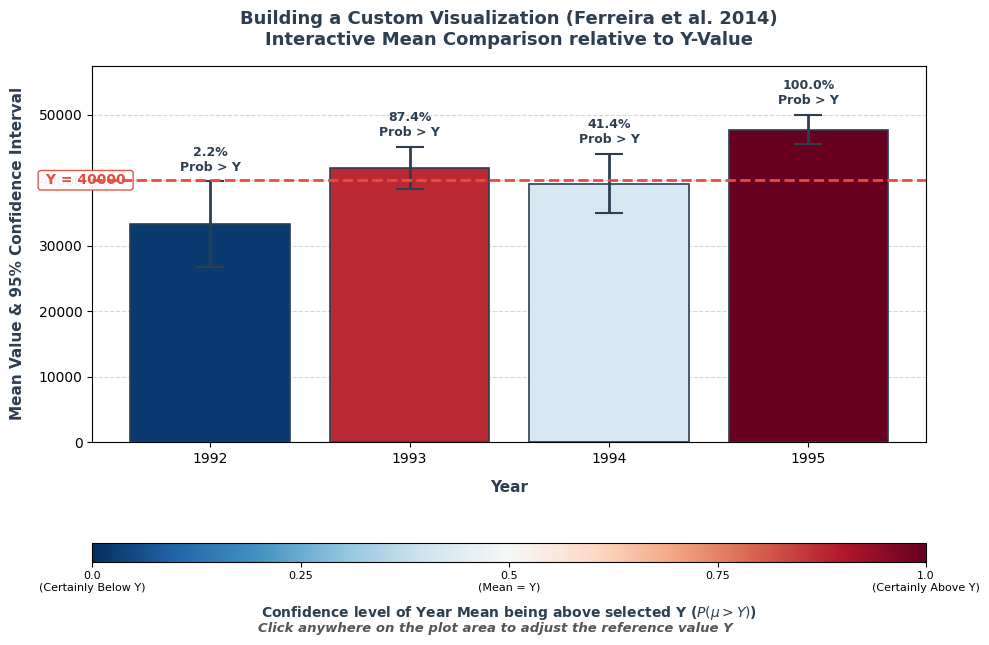

In [2]:
# To enable interactive clicking in Jupyter Notebook, uncomment the following line:
# %matplotlib notebook

#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Assignment 3 - Building a Custom Visualization
Ferreira, N., Fisher, D., & Konig, A. C. (2014)

This script provides an interactive bar chart of 4 years of data (1992-1995)
with 95% confidence intervals for the mean. Users can click anywhere on the 
y-axis to set a custom reference value. The bars will dynamically recolor 
using a color gradient (RdBu_r colormap) representing the probability of the 
mean of each year being above the selected reference value.

Usage:
    python assignment3.py
"""

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# 1. Setup the data exactly as defined in the assignment instructions
np.random.seed(12345)
df = pd.DataFrame([np.random.normal(32000, 200000, 3650), 
                   np.random.normal(43000, 100000, 3650), 
                   np.random.normal(43500, 140000, 3650), 
                   np.random.normal(48000, 70000, 3650)], 
                  index=[1992, 1993, 1994, 1995])

# Calculate statistics for each year
means = df.mean(axis=1)
stds = df.std(axis=1)
n = df.shape[1]
se = stds / np.sqrt(n)

# 95% confidence interval half-width: z = 1.96 (for sample size 3650)
yerr = 1.96 * se
years = df.index.astype(str)

# 2. Probability mapping calculation
# P(Mean > Y) = standard normal CDF((Mean - Y) / SE)
def get_probabilities(y_val):
    try:
        from scipy.stats import norm
        return norm.cdf((means - y_val) / se)
    except ImportError:
        # Fallback using standard library math.erf if scipy is not installed
        z = (means - y_val) / se
        # CDF of standard normal is 0.5 * (1 + erf(z / sqrt(2)))
        return 0.5 * (1 + np.vectorize(math.erf)(z / np.sqrt(2)))

# Initial reference value
y_interest = 40000.0
probs = get_probabilities(y_interest)

# 3. Setup the visualization
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.canvas.manager.set_window_title('Assignment 3: Custom Visualization')

# Select divergent colormap (Blue -> White -> Red reversed, so Red means above, Blue means below)
cmap = plt.colormaps.get_cmap('RdBu_r')
norm = Normalize(vmin=0, vmax=1)

# Plot the bars with error bars (95% CI)
bars = ax.bar(years, means, yerr=yerr, capsize=10,
              edgecolor='#2c3e50', linewidth=1.2, color=[cmap(p) for p in probs],
              error_kw=dict(ecolor='#2c3e50', elinewidth=2, capthick=1.5))

# Draw initial horizontal line at the reference value
hline = ax.axhline(y_interest, color='#e74c3c', linestyle='--', linewidth=2, zorder=5)

# Place text next to the line (aligned slightly left of the first bar)
y_text = ax.text(-0.4, y_interest, f' Y = {y_interest:.0f} ', color='#e74c3c', weight='bold',
                 fontsize=10, va='center', ha='right',
                 bbox=dict(facecolor='white', edgecolor='#e74c3c', boxstyle='round,pad=0.2', alpha=0.95, zorder=6))

# Add probability text labels above each bar
bar_texts = []
for i in range(len(years)):
    val = probs[i] * 100
    txt = ax.text(i, means.iloc[i] + yerr.iloc[i] + 1200, f'{val:.1f}%\nProb > Y',
                  ha='center', va='bottom', fontsize=9, color='#2c3e50', weight='bold')
    bar_texts.append(txt)

# Aesthetics
ax.set_title("Building a Custom Visualization (Ferreira et al. 2014)\nInteractive Mean Comparison relative to Y-Value", 
             fontsize=13, pad=15, weight='bold', color='#2c3e50')
ax.set_xlabel("Year", fontsize=11, labelpad=10, weight='semibold', color='#2c3e50')
ax.set_ylabel("Mean Value & 95% Confidence Interval", fontsize=11, labelpad=10, weight='semibold', color='#2c3e50')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Adjust y limits to make space for the label texts above bars
y_min, y_max = ax.get_ylim()
ax.set_ylim(0, y_max + 5000)

# Add horizontal colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.18, aspect=45)
cbar.set_label('Confidence level of Year Mean being above selected Y ($P(\\mu > Y)$)', 
               fontsize=10, weight='semibold', color='#2c3e50', labelpad=8)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(['0.0\n(Certainly Below Y)', '0.25', '0.5\n(Mean = Y)', '0.75', '1.0\n(Certainly Above Y)'])
cbar.ax.tick_params(labelsize=8)

# 4. Define interactive event handler
def onclick(event):
    # Ensure the click was inside the main axes
    if event.inaxes != ax:
        return
        
    y_val = event.ydata
    
    # Recalculate probabilities for new y value
    new_probs = get_probabilities(y_val)
    
    # Dynamically update the color of the bars
    for idx, bar in enumerate(bars):
        bar.set_facecolor(cmap(new_probs[idx]))
        
    # Update position and label of the horizontal line
    hline.set_ydata([y_val, y_val])
    y_text.set_position((-0.4, y_val))
    y_text.set_text(f' Y = {y_val:.0f} ')
    
    # Update the probability texts above each bar
    for idx, txt in enumerate(bar_texts):
        val = new_probs[idx] * 100
        txt.set_text(f'{val:.1f}%\nProb > Y')
        
    fig.canvas.draw_idle()

# Connect the click event to the handler
fig.canvas.mpl_connect('button_press_event', onclick)

# Add instructional prompt at the bottom of the figure
fig.text(0.5, 0.02, "Click anywhere on the plot area to adjust the reference value Y", 
         ha='center', fontsize=9.5, style='italic', color='#555555', weight='semibold')

plt.tight_layout()
plt.show()
